# Relatório de análise de performance e hábitos de estudantes
Relatório criado durante o curso de Fundamentos de IA e Análise de dados.

---
>**Observação**: base fictícia e totalmente open-source

### 1. Importação das Bibliotecas Necessárias
Carrega as bibliotecas do ecossistema Python para manipulação de dados (`pandas`) e visualização gráfica (`seaborn`).

In [1]:
import pandas as pd
import seaborn as sns

### 2. Leitura da Base de Dados
Carrega o arquivo CSV contendo o histórico de hábitos e notas de desempenho dos estudantes.

In [2]:
df = pd.read_csv(r".\data\dataset_aula03_student_habits_performance.csv")

### 3. Visualização das Primeiras Linhas do DataFrame
Exibe os 5 primeiros registros da tabela para entender a estrutura dos dados coletados.

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


### 4. Dimensão do Conjunto de Dados
Informa a quantidade total de linhas (estudantes) e colunas (variáveis de análise) contidas no DataFrame.

In [4]:
df.shape

(1000, 16)

### 5. Visualização das Últimas Linhas do DataFrame
Exibe os 5 últimos registros da base de dados.

In [5]:
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


### 6. Informações Gerais das Colunas
Gera um resumo técnico mostrando o tipo de dado de cada coluna, a memória utilizada e a presença de valores nulos (missing values).

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

### 7. Análise de Dados Faltantes
Calcula a quantidade exata de dados nulos ou vazios especificamente para a coluna do nível de escolaridade dos pais.

In [7]:
# Clean Code
valores_nulos = df["parental_education_level"].isna().sum()
print(f"A coluna de escolaridade possui {valores_nulos} dados desconhecidos.")

A coluna de escolaridade possui 91 dados desconhecidos.


### 8. Contagem de Valores Preenchidos
Mapeia o oposto do comando anterior, identificando quantos registros válidos e preenchidos existem na coluna informada.

In [8]:
valores_nao_nulos = df["parental_education_level"].notnull().sum()
print(f"A coluna de escolaridade dos pais possui {valores_nao_nulos} dados válidos.")

A coluna de escolaridade dos pais possui 909 dados válidos.


### 9. Tratamento de Dados Ausentes (`fillna`)
Preenche os valores vazios da escolaridade dos pais com a string `"Desconhecido"`, evitando que dados nulos quebrem futuras análises e modelos de IA.

In [9]:
# O comando "fillna()" preenche os valores nulos
df["parental_education_level"] = df["parental_education_level"].fillna("Desconhecido")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

### 10. Identificação das Categorias Existentes
Lista de maneira única quais são os graus de escolaridade dos pais que aparecem na base (eliminando repetições).

In [10]:
# Mostra o nome em sí
df["parental_education_level"].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Desconhecido']
Length: 4, dtype: str

### 11. Contagem do Número de Categorias
Informa o **número** total de grupos/categorias distintas existentes nessa coluna.

In [11]:
# Mostra o tipo
df["parental_education_level"].nunique()

4

### 12. Validação das Alterações
Executa o `info()` novamente para garantir que a coluna tratada agora apresenta 1000 registros não-nulos e que as alterações foram aplicadas corretamente.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

### 13. Seleção de Features Numéricas para Análise Visual
Cria uma lista filtrando apenas as colunas com dados numéricos contínuos (como idades, horas e pontuações) para preparar a geração de gráficos.

In [13]:
colunas = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

### 14. Matriz de Correlação Linear
Gera um mapa de calor (`heatmap`) para analisar a força e a direção da relação entre as variáveis numéricas. Valores próximos de 1 indicam correlação positiva forte, próximos de -1 indicam correlação negativa forte, e próximos de 0 indicam ausência de relação.

<Axes: >

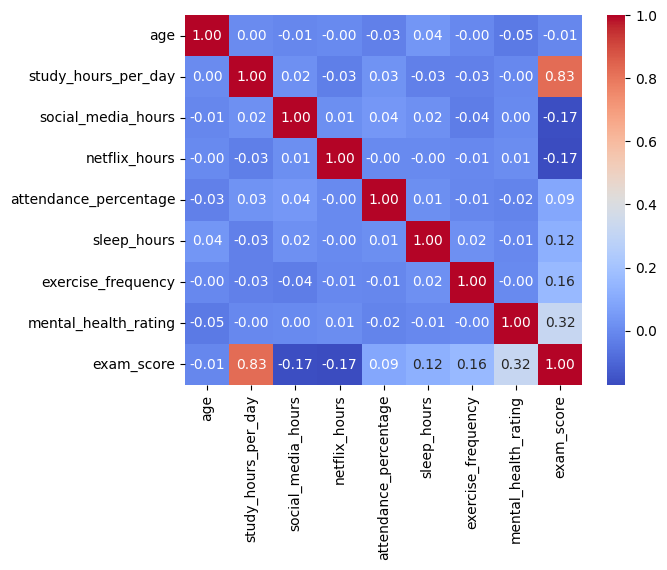

In [14]:
sns.heatmap(df[colunas].corr(), annot=True, fmt=".2f", cmap="coolwarm")

## RESULTADOS

##### **Coisas que mais influênciam em uma "exam_score" pontuação de uma prova.**

1.  Idade (age) influencia em *1%*

2.  Estudos de horas por dia (study_hours_per_day) influencia em *83%*

3.  Horas passadas em midias sociais (social_media_hours) influencia em *17%*

4.  Horas passadas na Netflix (netflix_hours) influencia em *17%*

5.  Frequencia de comparecimento em aulas (attendence_percentage) influencia em *9%*

6.  Horas dormidas (sleep_hours) influencia em *12%*

7.  Frequencia de exercicíos (exercise_frequency) influencia em *16%*

8. Raking de saude mantal (mental_health_rating) influencia em *32%*

### 15. Criação de Filtros de Horas de Estudo
Define critérios (máscaras booleanas) para segmentar os estudantes em dois grupos distintos com base na dedicação diária: alunos com carga horária alta (5 ou mais horas) e alunos com carga horária baixa (menos de 4 horas).

In [25]:
filtro_horas_altas = df["study_hours_per_day"] >= 5

filtro_horas_baixas = df["study_hours_per_day"] < 4

### 16. Comparação das Médias de Notas entre os Grupos
Calcula e exibe a nota média no exame para os dois grupos de estudantes filtrados anteriormente, permitindo avaliar o impacto direto do tempo de estudo no desempenho final.

In [26]:
media_pessoas_estudam_muito = df[filtro_horas_altas]["exam_score"].mean()

media_pessoas_estudam_pouco = df[filtro_horas_baixas]["exam_score"].mean()

print(media_pessoas_estudam_muito)

print(media_pessoas_estudam_pouco)

90.30059880239521
60.9030894308943


### 17. Print da Média das Pessoas que Estudam Muito

In [24]:
print(f"A média de alunos que estudam mais de 5 horas por dia e são aprovados é de: {media_pessoas_estudam_muito:.2f}%.")

A média de alunos que estudam mais de 5 horas por dia e são aprovados é de: 90.30%.


### 18. Gráfico de Regressão Linear (`lmplot`)
Plota um gráfico de dispersão combinando as horas de estudo com a nota do exame e desenha uma linha de tendência (regressão linear). Isso ajuda a visualizar de forma clara a relação de causa e efeito entre o tempo dedicado e o resultado obtido.

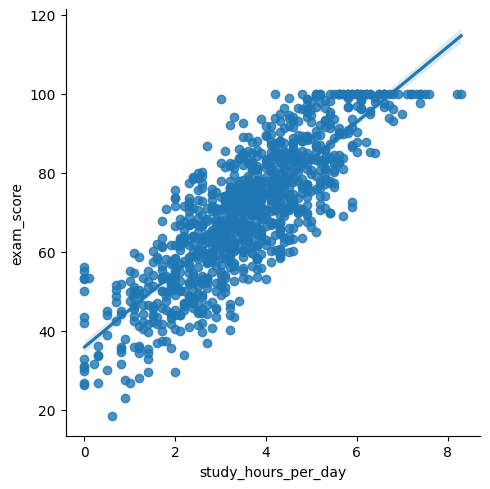

In [18]:
sns.lmplot(data=df, x="study_hours_per_day", y="exam_score");

### 19. Análise de Impacto do Tempo de Lazer (`lmplot`)
Gera um gráfico de dispersão com linha de tendência para avaliar a relação entre as horas gastas assistindo à Netflix e a nota final do exame. Isso permite observar se o aumento do tempo de lazer está associado a uma queda ou variação no desempenho dos estudantes.

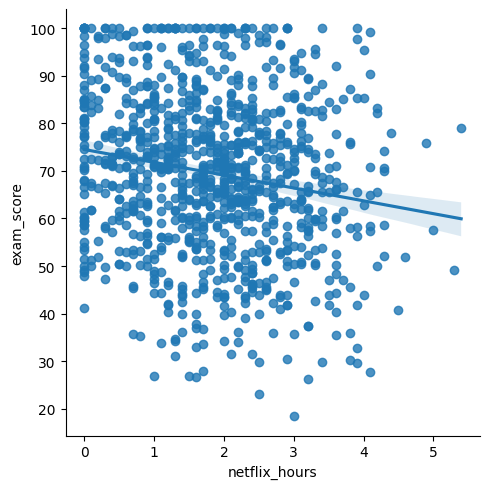

In [19]:
sns.lmplot(data=df, x="netflix_hours", y="exam_score");

### 20. Análise de Desempenho por Idade (`lmplot`)
Gera um gráfico de dispersão com linha de tendência para verificar se a idade dos estudantes possui alguma relação com a nota final do exame. Isso ajuda a identificar se alunos mais velhos ou mais novos apresentam comportamentos ou desempenhos diferentes.

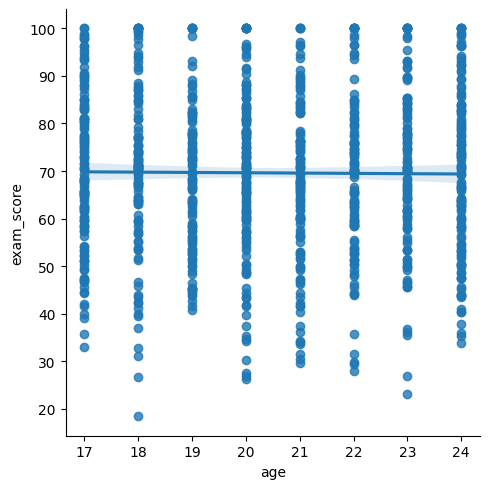

In [20]:
sns.lmplot(data=df, x="age", y="exam_score");

### 21. Análise de Correlação com a Saúde Mental (`lmplot`)
Gera um gráfico de dispersão com linha de tendência para avaliar o impacto da autoavaliação de saúde mental na nota final do exame. Isso permite analisar se estudantes que relatam melhor bem-estar psicológico tendem a alcançar desempenhos mais altos ou se há estabilidade nos resultados.

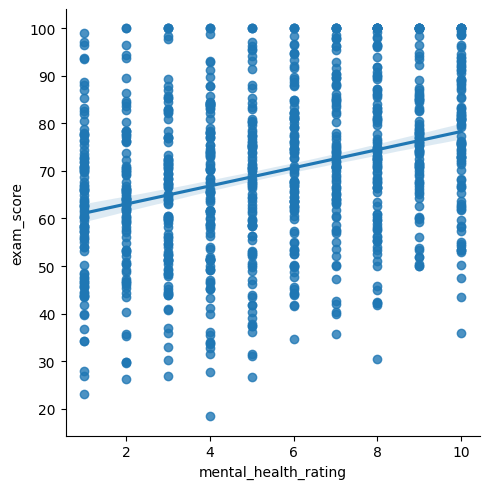

In [21]:
sns.lmplot(data=df, x="mental_health_rating", y="exam_score");

### 22. Gráfico de Auto-Correlação (`lmplot`)
Plota a variável da nota do exame contra ela mesma. Como estamos comparando um dado com ele próprio, o gráfico gerará uma linha reta perfeitamente diagonal e idêntica, servindo apenas para fins de validação visual ou demonstração de correlação perfeita positiva (coeficiente igual a 1).

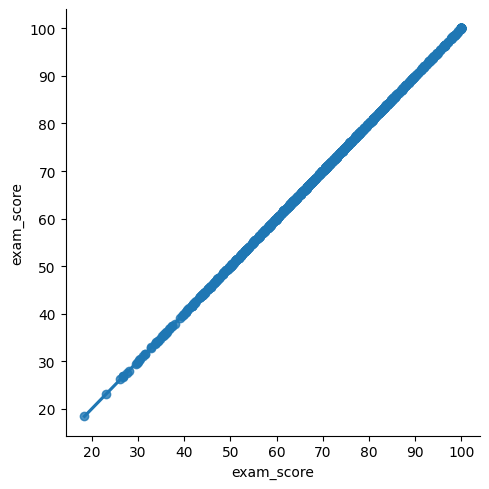

In [22]:
sns.lmplot(data=df, x="exam_score", y="exam_score");